## Gradient ascent example

This example shows a simple implementation of the gradient ascent algorithm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg' 
plt.style.use('bmh')

We define a two-variable function that we'd like to maximize. The true maximum is at $x=2$ and $y=-1$.

In [2]:
def f(x, y):
    return np.exp(-(x-2)**2 - (y+1)**2)

To get a feel for the function, let's make a plot. This is a function of two variables, so we'll create a three-dimensional surface plot.

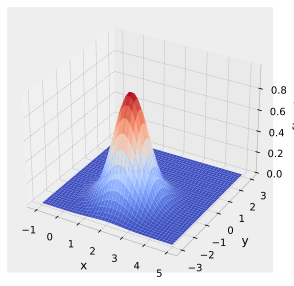

In [3]:
# The ranges of x and y values that we'd like to include in the contour plot.
x_range = np.linspace(-1, 5, 40)
y_range = np.linspace(-3, 3, 40)

# Form all possible x-y pairs in these ranges.
X, Y = np.meshgrid(x_range, y_range)

# Make the surface plot.
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, f(X, Y), cmap='coolwarm');

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)');

In [4]:
print(x_range)

[-1.         -0.84615385 -0.69230769 -0.53846154 -0.38461538 -0.23076923
 -0.07692308  0.07692308  0.23076923  0.38461538  0.53846154  0.69230769
  0.84615385  1.          1.15384615  1.30769231  1.46153846  1.61538462
  1.76923077  1.92307692  2.07692308  2.23076923  2.38461538  2.53846154
  2.69230769  2.84615385  3.          3.15384615  3.30769231  3.46153846
  3.61538462  3.76923077  3.92307692  4.07692308  4.23076923  4.38461538
  4.53846154  4.69230769  4.84615385  5.        ]


In [5]:
print(y_range)

[-3.         -2.84615385 -2.69230769 -2.53846154 -2.38461538 -2.23076923
 -2.07692308 -1.92307692 -1.76923077 -1.61538462 -1.46153846 -1.30769231
 -1.15384615 -1.         -0.84615385 -0.69230769 -0.53846154 -0.38461538
 -0.23076923 -0.07692308  0.07692308  0.23076923  0.38461538  0.53846154
  0.69230769  0.84615385  1.          1.15384615  1.30769231  1.46153846
  1.61538462  1.76923077  1.92307692  2.07692308  2.23076923  2.38461538
  2.53846154  2.69230769  2.84615385  3.        ]


In [6]:
i=1;
for x, y in zip(X, Y): 
    i = i+1

print(i)

41


As an alternative to the surface plot, the following code makes a two-dimensional *contour plot* that shows the surface of the function $f$. (Dark rings = lower values, light rings = higher values.)

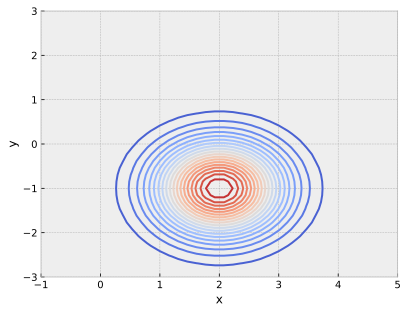

In [7]:
plt.contour(X, Y, f(X, Y), 20, cmap='coolwarm');
plt.xlabel('x')
plt.ylabel('y');

The gradient for our function with respect to the inputs $x$ and $y$. We can compute it by hand, or use some mathematical software (Maple, Mathematica, SageMath, Wolfram Alpha etc.)

The gradient of a function of two variables is a two-dimensional vector.

In [8]:
def gradient_of_f(x, y):
    return (-2*(x-2)*f(x, y), -2*(y+1)*f(x, y))

Here is the gradient ascent algorithm, which tries to locate the values of $x$ and $y$ that give the maximum of $f(x, y)$.

The inputs to `gradient_ascent` are the initial $x$ and $y$ values; a threshold that defines how small we expect the gradient to be when we have reached the maximum; and a step length parameter.

The function returns the $x$ and $y$ values that maximize the function. For pedagogical purposes, we also return a list called `history` of all the $x$-$y$ pairs that we have seen during the optimization procedure.

In [9]:
def gradient_ascent(x_init, y_init, 
                    threshold = 0.001,
                    steplength = 0.1):
    x = x_init
    y = y_init
    history = [(x, y)]
    done = False
    while not done:        
        gxy = gradient_of_f(x, y)
        x += steplength * gxy[0]
        y += steplength * gxy[1]
        history.append([x, y])
        if np.linalg.norm(gxy) < threshold:
            done = True
    return (x, y), history

We run the algorithm. As you can see, we get fairly close to the true best $x$ and $y$ values.

In [10]:
(x, y), history = gradient_ascent(0, 0)
print(x,y)
len(history)

1.999700102993721 -0.9998500514968605


138

Here is the contour plot again, including the path (red points) of the gradient ascent algorithm as it climbs from (0, 0) to the top (2, -1).

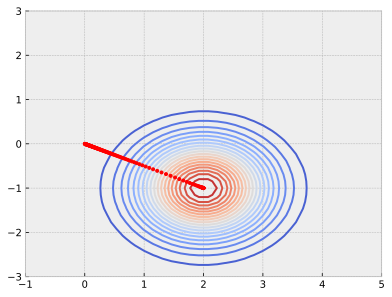

In [11]:
# Make the contour plot.
plt.contour(X, Y, f(X, Y), 20, cmap='coolwarm')

# Plot the gradient ascent path.
plt.plot([x for x, _ in history], [y for _, y in history], 'r.');